# Feature Engineering Pipeline

Builds the complete feature matrix for model training. Runs end-to-end — no intermediate files required.

**Output:** `df_model.csv` — one row per (station × year) for Italian PM2.5 stations.

| Feature | Source                                  |
|---|-----------------------------------------|
| PM2_5 | EEA annual median (target)              |
| NO2, PM10, O3 | EEA annual median (co-pollutants)       |
| Altitude, Latitude, Longitude | Station metadata                        |
| Station_Type, Station_Area | Station metadata                        |
| Green_Ratio | CORINE Land Cover 2018 (computed below) |
| Population_Density | UN/ISTAT population + comuni area       |

## Imports

In [4]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import requests
import time
from pathlib import Path


warnings.filterwarnings('ignore')

focus_pollutants = ['NO2', 'PM10', 'PM2.5', 'O3']
aggregation_id   = 'P1Y-day-per50'

print('Libraries loaded')

Libraries loaded


## Load Raw EEA Data

In [5]:
DATA = '2015-2024'

frames = []
for year in range(2015, 2025):
    path = os.path.join(DATA, f'DataExtract{year}.csv')
    frames.append(pd.read_csv(path, low_memory=False))

df = pd.concat(frames, ignore_index=True)
print(f'Combined: {df.shape[0]:,} rows')

Combined: 468,481 rows


## City Enrichment (fill missing City via comuni boundaries)

In [6]:
comuni = gpd.read_file('data_boundaries/comuni_2024/comuni_2024.shp').to_crs('EPSG:4326')
print('Comuni loaded:', comuni.shape)

Comuni loaded: (7899, 13)


In [7]:
df_it = df[df['Country'] == 'Italy'].dropna(subset=['Longitude', 'Latitude']).copy()

gdf_stations = gpd.GeoDataFrame(
    df_it,
    geometry=gpd.points_from_xy(df_it['Longitude'], df_it['Latitude']),
    crs='EPSG:4326'
)

joined = gpd.sjoin(
    gdf_stations[['Air Quality Station EoI Code', 'geometry']],
    comuni[['COMUNE', 'PRO_COM', 'geometry']],
    how='left',
    predicate='within'
)

station_to_city = (
    joined.dropna(subset=['COMUNE'])
    .groupby('Air Quality Station EoI Code')['COMUNE']
    .agg(lambda s: s.mode().iloc[0])
)

df['City'] = df['City'].astype('string').str.strip()
df.loc[df['City'] == '', 'City'] = pd.NA
it_mask = df['Country'] == 'Italy'
df.loc[it_mask, 'City'] = df.loc[it_mask, 'City'].fillna(
    df.loc[it_mask, 'Air Quality Station EoI Code'].map(station_to_city)
)

print(f'Italy missing City after enrichment: {df.loc[it_mask, "City"].isna().mean()*100:.2f}%')

Italy missing City after enrichment: 0.37%


## Build df_focus

In [8]:
df_focus = df[
    (df['Data Aggregation Process Id'] == aggregation_id) &
    (df['Air Pollutant'].isin(focus_pollutants))
].copy()

print(f'df_focus: {df_focus.shape[0]:,} rows')

df_focus: 17,010 rows


## Population Data

In [9]:
UN_POP_PATH = 'UNdata_Export_20260312_103717571.csv'

un_raw = pd.read_csv(UN_POP_PATH)
un_pop = (
    un_raw.loc[
        (un_raw['Country or Area'] == 'Italy') & (un_raw['Sex'] == 'Both Sexes'),
        ['Year', 'City', 'Value'],
    ]
    .rename(columns={'Value': 'Population_UN'})
    .copy()
)
un_pop['Year'] = un_pop['Year'].astype(int)

def normalize_city_for_merge(s):
    if pd.isna(s):
        return s
    return str(s).strip().lower()

un_pop['City_norm'] = un_pop['City'].apply(normalize_city_for_merge)

years_full = list(range(2015, 2025))
filled = []
for (city_norm, city_orig), grp in un_pop.groupby(['City_norm', 'City']):
    by_year = grp.set_index('Year')['Population_UN']
    years_in_grp = sorted(by_year.index)
    for y in years_full:
        if y in by_year.index:
            filled.append({'City_norm': city_norm, 'City': city_orig, 'Year': y, 'Population_UN': by_year.loc[y]})
        else:
            prev_y = [vy for vy in years_in_grp if vy < y]
            next_y = [vy for vy in years_in_grp if vy > y]
            prev_val = by_year.loc[prev_y[-1]] if prev_y else np.nan
            next_val = by_year.loc[next_y[0]] if next_y else np.nan
            if pd.notna(prev_val) and pd.notna(next_val):
                pop_fill = min(prev_val, next_val)
            elif pd.notna(prev_val):
                pop_fill = prev_val
            elif pd.notna(next_val):
                pop_fill = next_val
            else:
                continue
            filled.append({'City_norm': city_norm, 'City': city_orig, 'Year': y, 'Population_UN': pop_fill})

un_pop_filled = pd.DataFrame(filled)
# Fix UN city name casing — 'ROMA' → 'Roma'
un_pop_filled['City'] = un_pop_filled['City'].str.title()
print(f'UN population rows: {len(un_pop_filled)}')

# ── ISTAT fallback ──
ISTAT_POP_PATH = 'ISTAT_pop2024.csv'
istat_raw = pd.read_csv(ISTAT_POP_PATH, low_memory=False)

istat_pop = (
    istat_raw[
        (istat_raw['Territory'] != 'Italy') &
        (istat_raw['TIME_PERIOD'] == '2024-12')
    ]
    [['Territory', 'Observation']]
    .rename(columns={'Territory': 'City_ISTAT', 'Observation': 'Population_ISTAT'})
    .dropna(subset=['Population_ISTAT'])
    .copy()
)
istat_pop['City_norm'] = istat_pop['City_ISTAT'].apply(normalize_city_for_merge)
print(f'ISTAT comuni loaded: {len(istat_pop)}')

UN population rows: 450
ISTAT comuni loaded: 7896


## Population Density

In [10]:
_comuni_area = comuni[['COMUNE', 'Shape_Area']].copy()
_comuni_area['City_norm'] = _comuni_area['COMUNE'].apply(normalize_city_for_merge)
_comuni_area['City_Area_km2'] = (_comuni_area['Shape_Area'] / 1e6).round(1)

# ── UN primary ──
_latest = int(un_pop_filled['Year'].max())
_un = (
    un_pop_filled[un_pop_filled['Year'] == _latest]
    [['City', 'City_norm', 'Population_UN']]
    .drop_duplicates(subset='City_norm')
    .rename(columns={'Population_UN': 'City_Population'})
    .merge(_comuni_area[['City_norm', 'City_Area_km2']], on='City_norm', how='left')
    .dropna(subset=['City_Area_km2'])
)
_un['Pop_Density'] = (_un['City_Population'] / _un['City_Area_km2']).round(0)

# ── ISTAT fallback — only cities NOT in UN ──
_un_cities = set(_un['City_norm'])
_istat = (
    istat_pop[~istat_pop['City_norm'].isin(_un_cities)]
    .merge(_comuni_area[['City_norm', 'City_Area_km2']], on='City_norm', how='left')
    .dropna(subset=['City_Area_km2'])
    .drop_duplicates(subset='City_norm')
    .assign(
        City=lambda d: d['City_ISTAT'],
        City_Population=lambda d: d['Population_ISTAT'],
        Pop_Density=lambda d: (d['Population_ISTAT'] / d['City_Area_km2']).round(0)
    )
    [['City', 'City_norm', 'City_Population', 'City_Area_km2', 'Pop_Density']]
)

# ── Combine ──
pop_density_cities = (
    pd.concat([_un, _istat], ignore_index=True)
    .drop_duplicates(subset='City_norm')
    [['City', 'City_norm', 'City_Population', 'City_Area_km2', 'Pop_Density']]
)

# ── Add EEA-style aliases for (greater city) variants ──
_eea_cities = (
    df[['City']].dropna().drop_duplicates().copy()
)
_eea_cities['City_norm'] = (
    _eea_cities['City'].str.strip().str.lower()
    .str.replace(r'\s*\(.*?\)', '', regex=True).str.strip()
)
_eea_aliases = (
    _eea_cities
    .merge(
        pop_density_cities[['City_norm', 'City_Population', 'City_Area_km2', 'Pop_Density']],
        on='City_norm', how='inner'
    )
)
pop_density_cities = (
    pd.concat([pop_density_cities, _eea_aliases], ignore_index=True)
    .drop_duplicates(subset='City')
    [['City', 'City_norm', 'City_Population', 'City_Area_km2', 'Pop_Density']]
)

print(f'UN matched:           {len(_un)}')
print(f'ISTAT fallback added: {len(_istat)}')
print(f'Total after aliases:  {len(pop_density_cities)}')

UN matched:           43
ISTAT fallback added: 7531
Total after aliases:  7578


## CORINE Land Cover 2018 — Green Space Ratio

For each station we compute the **green_ratio** of its comune:

> `green_ratio = (agricultural + forest area) / total comune area`

A continuous 0–1 feature: 0 = fully urban, 1 = fully green.  
This carries more predictive signal than the raw categorical CLC class (76% of stations sit on Artificial surfaces).

**Dataset:** CORINE Land Cover 2018 (vector, 100 m), Europe — GDB, NUTS: Italia  
**Source:** European Environment Agency (EEA)

In [11]:
GDB_PATH = 'LandCover2018/U2018_CLC2018_V2020_20u1.gdb'
LAYER    = 'U2018_CLC2018_V2020_20u1'

clc = gpd.read_file(GDB_PATH, layer=LAYER)
print('CORINE shape:', clc.shape)
print('CRS:', clc.crs)

CORINE shape: (112742, 7)
CRS: EPSG:3035


In [12]:
# Create Level-1 and Level-2 helper columns
clc['clc_l1'] = clc['Code_18'].astype(str).str[0]
clc['clc_l2'] = clc['Code_18'].astype(str).str[:2]

L1_LABELS = {
    '1': 'Artificial surfaces',
    '2': 'Agricultural areas',
    '3': 'Forest & semi-natural',
    '4': 'Wetlands',
    '5': 'Water bodies'
}
clc['clc_l1_label'] = clc['clc_l1'].map(L1_LABELS)
print('Unrecognised codes:', clc['clc_l1_label'].isna().sum())

# Reproject to WGS84 to match station coordinates
clc = clc.to_crs('EPSG:4326')
print('CRS now:', clc.crs)

Unrecognised codes: 0
CRS now: EPSG:4326


In [13]:
# Unique Italian stations with coordinates (reuse data already loaded above)
stations = (
    df[
        (df['Country'] == 'Italy') &
        df['Latitude'].notna() &
        df['Longitude'].notna()
    ][['Air Quality Station EoI Code', 'Latitude', 'Longitude']]
    .drop_duplicates(subset='Air Quality Station EoI Code')
    .reset_index(drop=True)
)

gdf_stations_unique = gpd.GeoDataFrame(
    stations,
    geometry=gpd.points_from_xy(stations['Longitude'], stations['Latitude']),
    crs='EPSG:4326'
)
print(f'Unique Italian stations: {len(gdf_stations_unique)}')

Unique Italian stations: 796


In [14]:
# Assign land cover to each station via spatial join
clc_slim = clc[['Code_18', 'clc_l1', 'clc_l2', 'clc_l1_label', 'geometry']].copy()

joined_clc = gpd.sjoin(
    gdf_stations_unique,
    clc_slim,
    how='left',
    predicate='within'
).drop(columns=['index_right'], errors='ignore')

matched = joined_clc['Code_18'].notna().sum()
print(f'Matched: {matched} / {len(joined_clc)} stations ({matched/len(joined_clc)*100:.1f}%)')

# Fallback for unmatched: nearest polygon within ~5 km
unmatched = joined_clc['Code_18'].isna()
if unmatched.sum() > 0:
    fallback = gpd.sjoin_nearest(
        gdf_stations_unique[unmatched],
        clc_slim,
        how='left',
        max_distance=0.05
    ).drop(columns=['index_right'], errors='ignore')
    fill_cols = ['Code_18', 'clc_l1', 'clc_l2', 'clc_l1_label']
    joined_clc.loc[unmatched, fill_cols] = (
        fallback.set_index('Air Quality Station EoI Code')[fill_cols]
        .reindex(joined_clc.loc[unmatched, 'Air Quality Station EoI Code'])
        .values
    )
    print(f'Still unmatched after fallback: {joined_clc["Code_18"].isna().sum()}')

Matched: 794 / 796 stations (99.7%)
Still unmatched after fallback: 0


In [15]:
# Calculate green_ratio per comune:
# green_ratio = (agricultural 2xx + forest 3xx area) / total comune area

clc_green = clc_slim[clc_slim['clc_l1'].isin(['2', '3'])].copy()

comuni['total_area'] = comuni.geometry.area

green_in_comuni = gpd.overlay(clc_green, comuni[['COMUNE', 'geometry']], how='intersection')
green_in_comuni['green_area'] = green_in_comuni.geometry.area

green_per_comune = (
    green_in_comuni.groupby('COMUNE')['green_area']
    .sum()
    .reset_index()
    .rename(columns={'green_area': 'total_green_area'})
)

comuni = comuni.merge(green_per_comune, on='COMUNE', how='left')
comuni['total_green_area'] = comuni['total_green_area'].fillna(0)
comuni['green_ratio'] = comuni['total_green_area'] / comuni['total_area']

print('green_ratio summary:')
print(comuni['green_ratio'].describe().round(3))

green_ratio summary:
count    7899.000
mean        0.903
std         0.167
min         0.000
25%         0.880
50%         0.955
75%         0.986
max         7.911
Name: green_ratio, dtype: float64


In [16]:
# Assign green_ratio to each station via its comune
stations_comuni = gpd.sjoin(
    gdf_stations_unique,
    comuni[['COMUNE', 'green_ratio', 'geometry']],
    how='left',
    predicate='within'
).drop(columns=['index_right'], errors='ignore')

# Build the green feature table
df_green = stations_comuni[[
    'Air Quality Station EoI Code', 'Latitude', 'Longitude', 'COMUNE', 'green_ratio'
]].copy()

# Fill any remaining missing with the national median
df_green['green_ratio'] = df_green['green_ratio'].fillna(df_green['green_ratio'].median())

print(f'Stations with green_ratio: {df_green["green_ratio"].notna().sum()} / {len(df_green)}')

Stations with green_ratio: 796 / 796


In [17]:
# Save green_ratio so eda.ipynb can load it for visualisations
GREEN_OUTPUT = 'LandCover2018/green_ratio.csv'
df_green.to_csv(GREEN_OUTPUT, index=False)
print(f'Saved {len(df_green):,} rows -> {GREEN_OUTPUT}')

Saved 796 rows -> LandCover2018/green_ratio.csv


## Build df_model

In [18]:
# Step 1: pivot pollutants — one row per station x year
pivot = (
    df_focus
    .groupby(['Air Quality Station EoI Code', 'Year', 'Air Pollutant'])['Air Pollution Level']
    .median()
    .unstack('Air Pollutant')
    .reset_index()
)
pivot = pivot.dropna(subset=['PM2.5'])  # keep only rows with a PM2.5 measurement

# ── Step 2: station-level metadata ──
meta_cols = [
    'Air Quality Station EoI Code',
    'Altitude', 'Latitude', 'Longitude',
    'Air Quality Station Type',
    'Air Quality Station Area',
    'City'
]
station_meta = (
    df_focus[meta_cols]
    .drop_duplicates(subset='Air Quality Station EoI Code')
)

# ── Step 3: merge metadata ──
df_model = pivot.merge(station_meta, on='Air Quality Station EoI Code', how='left')

# ── Step 4: merge green ratio ──
df_model = df_model.merge(
    df_green[['Air Quality Station EoI Code', 'green_ratio']],
    on='Air Quality Station EoI Code',
    how='left'
)

# ── Step 5: merge population density ──
_density_map = pop_density_cities.set_index('City')['Pop_Density']
_station_city = (
    df_focus[['Air Quality Station EoI Code', 'City']]
    .drop_duplicates(subset='Air Quality Station EoI Code')
    .set_index('Air Quality Station EoI Code')['City']
)
df_model['Population_Density'] = (
    df_model['Air Quality Station EoI Code']
    .map(_station_city)
    .map(_density_map)
)

# ── Step 6: clean column names ──
df_model = df_model.rename(columns={
    'PM2.5':                    'PM2_5',
    'Air Quality Station Type': 'Station_Type',
    'Air Quality Station Area': 'Station_Area',
    'green_ratio':              'Green_Ratio',
})

print('df_model shape:', df_model.shape)
print('\nMissing values per column:')
print(df_model.isnull().sum())
df_model.head()

df_model shape: (2578, 14)

Missing values per column:
Air Quality Station EoI Code      0
Year                              0
NO2                              85
O3                              993
PM10                            139
PM2_5                             0
Altitude                          1
Latitude                          0
Longitude                         0
Station_Type                      0
Station_Area                      0
City                              0
Green_Ratio                       0
Population_Density               46
dtype: int64


,Air Quality Station EoI Code,Year,NO2,O3,PM10,PM2_5,Altitude,Latitude,Longitude,Station_Type,Station_Area,City,Green_Ratio,Population_Density
0,IT0459A,2015,26.008,40.896,26.225,11.321,15.0,43.5989,13.3419,Background,Suburban,Chiaravalle,0.813059,788.0
1,IT0459A,2016,23.654,41.158,22.392,9.496,15.0,43.5989,13.3419,Background,Suburban,Chiaravalle,0.813059,788.0
2,IT0459A,2017,25.579,49.442,21.329,9.133,15.0,43.5989,13.3419,Background,Suburban,Chiaravalle,0.813059,788.0
3,IT0459A,2018,28.517,44.710,24.763,10.488,15.0,43.5989,13.3419,Background,Suburban,Chiaravalle,0.813059,788.0
4,IT0459A,2019,25.850,44.975,24.117,11.696,15.0,43.5989,13.3419,Background,Suburban,Chiaravalle,0.813059,788.0


## Feature Correlation Heatmap

To check whether all selected features carry independent information, we compute pairwise Pearson correlations across all numeric columns in `df_model`.

Categorical features (`Station_Type`, `Station_Area`) are label-encoded numerically for this analysis only — they are not modified in `df_model`.

**What to look for:** features with |r| > 0.9 are nearly redundant and one can likely be dropped before modeling.

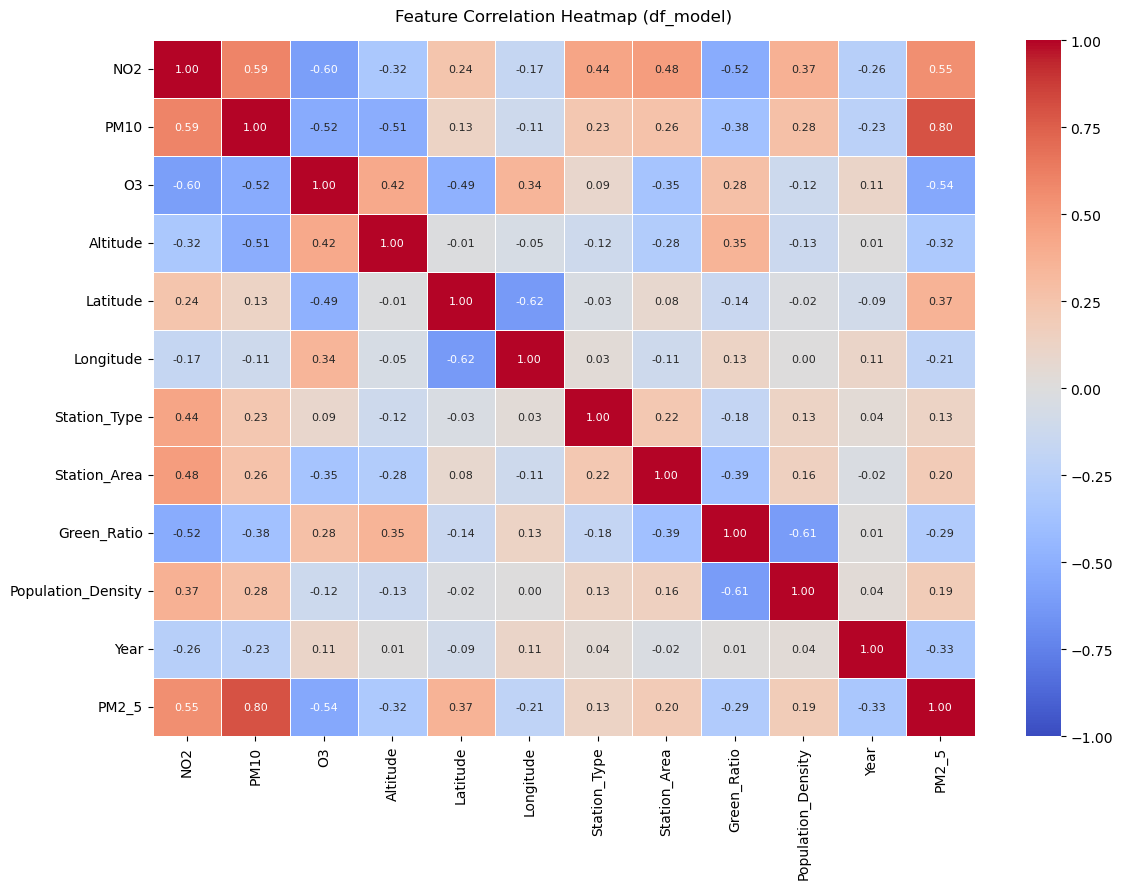

In [19]:
# Numeric columns available in df_model
numeric_cols = ["NO2", "PM10", "O3",
                "Altitude", "Latitude", "Longitude",
                "Green_Ratio", "Population_Density", "Year", "PM2_5"]

df_corr = df_model[numeric_cols].copy()

# Label-encode categoricals for correlation purposes only
df_corr["Station_Type"] = df_model["Station_Type"].astype("category").cat.codes
df_corr["Station_Area"] = df_model["Station_Area"].astype("category").cat.codes

# Reorder: features first, target (PM2_5) last
feature_order = ["NO2", "PM10", "O3",
                 "Altitude", "Latitude", "Longitude",
                 "Station_Type", "Station_Area",
                 "Green_Ratio", "Population_Density", "Year",
                 "PM2_5"]
df_corr = df_corr[feature_order]

corr = df_corr.corr()

plt.figure(figsize=(12, 9))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    linewidths=0.5,
    annot_kws={"size": 8}
)
plt.title("Feature Correlation Heatmap (df_model)", pad=14)
plt.tight_layout()
plt.savefig("images/df_model_feature_correlation.png", dpi=300)
plt.show()

## Export

In [20]:
OUTPUT = 'df_model.csv'
df_model.to_csv(OUTPUT, index=False)
print(f'Saved {len(df_model):,} rows -> {OUTPUT}')
print('Columns:', df_model.columns.tolist())

Saved 2,578 rows -> df_model.csv
Columns: ['Air Quality Station EoI Code', 'Year', 'NO2', 'O3', 'PM10', 'PM2_5', 'Altitude', 'Latitude', 'Longitude', 'Station_Type', 'Station_Area', 'City', 'Green_Ratio', 'Population_Density']


## Monthly Enrichment via OpenAQ

### Why monthly data?
Annual averages mask the seasonal dynamics that drive PM2.5 risk.
A city planner needs to know *when* pollution spikes, not just that it's bad on average.
Monthly resolution reveals patterns like winter temperature inversions in the Po Valley,
spring agricultural burning, or summer ozone formation — insights that annual data
completely hides.

### Step 1: Station Coverage Check
Match each EEA station to the nearest OpenAQ location within 1km using coordinates.
Result is cached in `openaq/openaq_coverage.csv` so it only runs once.

In [21]:
OPENAQ_KEY = "df5b0efc568c0f8dd158759338d21a77098985124bddd3720d7d37a97644e65b"
HEADERS = {"X-API-Key": OPENAQ_KEY}

Path("openaq").mkdir(exist_ok=True)

# ── Check if coverage already exists ──
COVERAGE_PATH = "openaq/openaq_coverage.csv"

if Path(COVERAGE_PATH).exists():
    coverage_df = pd.read_csv(COVERAGE_PATH)
    print(f"Coverage already exists — loaded {len(coverage_df)} stations, skipping API calls.")
    matched = coverage_df[coverage_df["openaq_found"] > 0]
    print(f"Matched: {len(matched)} / {len(coverage_df)} ({len(matched)/len(coverage_df):.1%})")
else:
    print("No existing coverage found — running API calls...")

    df_model = pd.read_csv("df_model.csv")
    stations = (
        df_model[["Air Quality Station EoI Code", "Latitude", "Longitude", "City"]]
        .drop_duplicates(subset="Air Quality Station EoI Code")
        .reset_index(drop=True)
    )
    print(f"Total stations: {len(stations)}")

    results = []
    for i, row in stations.iterrows():
        try:
            resp = requests.get(
                "https://api.openaq.org/v3/locations",
                params={
                    "coordinates": f"{row['Latitude']},{row['Longitude']}",
                    "radius": 1000,
                    "limit": 5,
                },
                headers=HEADERS,
                timeout=10
            )
            data = resp.json()
            found = data.get("meta", {}).get("found", 0)
            results.append({
                "eoi_code":     row["Air Quality Station EoI Code"],
                "city":         row["City"],
                "lat":          row["Latitude"],
                "lon":          row["Longitude"],
                "openaq_found": found,
                "openaq_id":    data["results"][0]["id"] if found > 0 else None,
                "openaq_name":  data["results"][0]["name"] if found > 0 else None,
            })
        except Exception as e:
            results.append({
                "eoi_code":     row["Air Quality Station EoI Code"],
                "city":         row["City"],
                "lat":          row["Latitude"],
                "lon":          row["Longitude"],
                "openaq_found": -1,
                "openaq_id":    None,
                "openaq_name":  None,
            })

        if i % 25 == 0:
            print(f"  {i}/{len(stations)} done...")
        time.sleep(1.1)

    coverage_df = pd.DataFrame(results)
    matched = coverage_df[coverage_df["openaq_found"] > 0]
    print(f"\nMatched:   {len(matched)} / {len(stations)} ({len(matched)/len(stations):.1%})")
    print(f"Not found: {len(coverage_df[coverage_df['openaq_found'] == 0])}")
    print(f"Errors:    {len(coverage_df[coverage_df['openaq_found'] == -1])}")

    coverage_df.to_csv(COVERAGE_PATH, index=False)
    print(f"Saved to {COVERAGE_PATH}")

Coverage already exists — loaded 371 stations, skipping API calls.
Matched: 335 / 371 (90.3%)


### Step 2: Sensor Discovery
For each matched OpenAQ location, retrieve sensor IDs for PM2.5, PM10, NO2 and O3.
Each location can have multiple sensors — one per pollutant.
Result is cached in `openaq/openaq_sensors.csv`.

In [22]:
# Check actual API response structure for one location
test_loc_id = int(coverage_df[coverage_df["openaq_found"] > 0]["openaq_id"].iloc[0])
print(f"Testing location ID: {test_loc_id}")

resp = requests.get(
    f"https://api.openaq.org/v3/locations/{test_loc_id}/sensors",
    headers=HEADERS,
    timeout=10
)
print("Status:", resp.status_code)

import json
data = resp.json()
print("Full response:")
print(json.dumps(data, indent=2))

Testing location ID: 8223
Status: 200
Full response:
{
  "meta": {
    "name": "openaq-api",
    "website": "/",
    "page": 1,
    "limit": 100,
    "found": 6
  },
  "results": [
    {
      "id": 24570,
      "name": "o3 \u00b5g/m\u00b3",
      "parameter": {
        "id": 3,
        "name": "o3",
        "units": "\u00b5g/m\u00b3",
        "displayName": "O\u2083 mass"
      },
      "datetimeFirst": {
        "utc": "2020-05-06T16:00:00Z",
        "local": "2020-05-06T18:00:00+02:00"
      },
      "datetimeLast": {
        "utc": "2026-04-15T01:00:00Z",
        "local": "2026-04-15T03:00:00+02:00"
      },
      "coverage": {
        "expectedCount": 1,
        "expectedInterval": "01:00:00",
        "observedCount": 26098,
        "observedInterval": "26098:00:00",
        "percentComplete": 2609800.0,
        "percentCoverage": 2609800.0,
        "datetimeFrom": {
          "utc": "2020-05-06T16:00:00Z",
          "local": "2020-05-06T18:00:00+02:00"
        },
        "datetim

In [23]:
# Step 2: Get sensor IDs for matched stations
SENSORS_PATH = "openaq/openaq_sensors.csv"

if Path(SENSORS_PATH).exists():
    sensors_df = pd.read_csv(SENSORS_PATH)
    print(f"Sensors already exist — loaded {len(sensors_df)} sensors, skipping API calls.")
    print(sensors_df["parameter"].value_counts())
else:
    print("No existing sensors found — running API calls...")

    PARAM_MAP = {
        "pm25": "PM2_5",
        "pm10": "PM10",
        "no2":  "NO2",
        "o3":   "O3",
    }

    coverage_df = pd.read_csv("openaq/openaq_coverage.csv")
    matched = coverage_df[coverage_df["openaq_found"] > 0].copy()
    unique_locations = matched.drop_duplicates(subset="openaq_id").reset_index(drop=True)
    print(f"Unique OpenAQ locations to fetch sensors for: {len(unique_locations)}")

    sensor_rows = []
    for i, row in unique_locations.iterrows():
        loc_id = int(row["openaq_id"])
        try:
            resp = requests.get(
                f"https://api.openaq.org/v3/locations/{loc_id}/sensors",
                headers=HEADERS,
                timeout=10
            )
            data = resp.json()
            for sensor in data.get("results", []):
                param = sensor["parameter"]["name"].lower()
                if param in PARAM_MAP:
                    sensor_rows.append({
                        "openaq_id":    loc_id,
                        "sensor_id":    sensor["id"],
                        "parameter":    param,
                        "col_name":     PARAM_MAP[param],
                        "date_first":   sensor["datetimeFirst"]["utc"][:10],
                        "date_last":    sensor["datetimeLast"]["utc"][:10],
                    })
        except Exception as e:
            print(f"  Error for location {loc_id}: {e}")

        if i % 50 == 0:
            print(f"  {i}/{len(unique_locations)} done...")
        time.sleep(1.1)

    sensors_df = pd.DataFrame(sensor_rows)
    print(f"\nTotal sensors found: {len(sensors_df)}")
    print(sensors_df["parameter"].value_counts())

    # Check date coverage
    sensors_df["date_first"] = pd.to_datetime(sensors_df["date_first"])
    print(f"\nSensors starting before 2016: {(sensors_df['date_first'] < '2016-01-01').sum()}")
    print(f"Sensors starting 2016-2019:   {((sensors_df['date_first'] >= '2016-01-01') & (sensors_df['date_first'] < '2020-01-01')).sum()}")
    print(f"Sensors starting 2020+:       {(sensors_df['date_first'] >= '2020-01-01').sum()}")

    sensors_df.to_csv(SENSORS_PATH, index=False)
    print(f"\nSaved to {SENSORS_PATH}")

Sensors already exist — loaded 810 sensors, skipping API calls.
parameter
no2     303
o3      182
pm25    165
pm10    160
Name: count, dtype: int64


### Step 3: Monthly Data Pull
Fetch monthly aggregated measurements per sensor for 2020–2024.

**Why 2020 onwards?**
The sensor discovery step revealed that OpenAQ coverage for Italian stations is heavily
skewed towards recent years:
- 0 sensors available before 2017
- Only 20 PM2.5 sensors available before 2020
- 145 PM2.5 sensors starting from 2020 onwards

Since PM2.5 is our target variable, training on years where it is almost entirely missing
would introduce systematic bias. Restricting to 2020–2024 gives us a clean, consistent
monthly dataset with real measurements rather than imputed annual fallbacks.

Uses the `/v3/sensors/{id}/days/monthly` endpoint.
Result is cached in `openaq/openaq_monthly_raw.csv`.

In [24]:
# Step 3: Pull monthly measurements per sensor
MONTHLY_PATH = "openaq/openaq_monthly_raw.csv"

if Path(MONTHLY_PATH).exists():
    monthly_raw = pd.read_csv(MONTHLY_PATH)
    print(f"Monthly data already exists — loaded {len(monthly_raw)} rows, skipping API calls.")
else:
    print("Pulling monthly data from OpenAQ...")

    sensors_df = pd.read_csv("openaq/openaq_sensors.csv")
    sensors_df["date_first"] = pd.to_datetime(sensors_df["date_first"])

    monthly_rows = []
    total = len(sensors_df)

    for i, row in sensors_df.iterrows():
        sensor_id = int(row["sensor_id"])
        try:
            resp = requests.get(
                f"https://api.openaq.org/v3/sensors/{sensor_id}/days/monthly",
                params={
                    "date_from": "2020-01-01",
                    "date_to":   "2025-12-31",
                    "limit":     120,  # max 10 years x 12 months
                },
                headers=HEADERS,
                timeout=15
            )
            data = resp.json()
            for m in data.get("results", []):
                monthly_rows.append({
                    "sensor_id":   sensor_id,
                    "openaq_id":   int(row["openaq_id"]),
                    "parameter":   row["parameter"],
                    "col_name":    row["col_name"],
                    "year":        int(m["period"]["datetimeFrom"]["utc"][:4]),
                    "month":       int(m["period"]["datetimeFrom"]["utc"][5:7]),
                    "value":       m["value"],
                })
        except Exception as e:
            print(f"  Error sensor {sensor_id}: {e}")

        if i % 100 == 0:
            print(f"  {i}/{total} sensors done...")
        time.sleep(1.1)

    monthly_raw = pd.DataFrame(monthly_rows)
    print(f"\nTotal monthly records pulled: {len(monthly_raw)}")
    print(monthly_raw["parameter"].value_counts())
    print(f"\nYear range: {monthly_raw['year'].min()} - {monthly_raw['year'].max()}")

    monthly_raw.to_csv(MONTHLY_PATH, index=False)
    print(f"Saved to {MONTHLY_PATH}")

Monthly data already exists — loaded 29922 rows, skipping API calls.


### Step 4: Join & Reshape
Merge OpenAQ monthly data with EEA station metadata and static features.


In [25]:
# Step 4: Clean, join and reshape to monthly df_model
monthly_raw  = pd.read_csv("openaq/openaq_monthly_raw.csv")
coverage_df  = pd.read_csv("openaq/openaq_coverage.csv")
df_model_annual = pd.read_csv("df_model.csv")

# Clean raw monthly data
monthly_raw = monthly_raw[
    (monthly_raw["year"] >= 2020) &   # strict 2020+ cutoff
    (monthly_raw["value"] >= 0) &     # drop negative sensor errors
    (monthly_raw["value"] <= 500)     # drop extreme outliers (7800 etc)
].copy()

print(f"After cleaning: {len(monthly_raw)} records")
print(monthly_raw["parameter"].value_counts())

# Pivot: one row per openaq_id x year x month, pollutants as columns
monthly_pivot = monthly_raw.pivot_table(
    index=["openaq_id", "year", "month"],
    columns="col_name",
    values="value",
    aggfunc="median"   # in case multiple sensors per location/pollutant
).reset_index()

monthly_pivot.columns.name = None
print(f"\nPivoted shape: {monthly_pivot.shape}")
print(monthly_pivot.head(3))

# Join EEA station metadata via openaq_id
# Map openaq_id → eoi_code using coverage file
id_to_eoi = (
    coverage_df[coverage_df["openaq_found"] > 0]
    [["openaq_id", "eoi_code"]]
    .drop_duplicates(subset="openaq_id")
)

monthly_pivot = monthly_pivot.merge(id_to_eoi, on="openaq_id", how="left")

# Join static features from annual df_model
# Static features don't change by month — take one row per station
static_cols = [
    "Air Quality Station EoI Code",
    "Altitude", "Latitude", "Longitude",
    "Station_Type", "Station_Area",
    "City", "Green_Ratio", "Population_Density"
]
static = (
    df_model_annual[static_cols]
    .drop_duplicates(subset="Air Quality Station EoI Code")
    .rename(columns={"Air Quality Station EoI Code": "eoi_code"})
)

df_monthly = monthly_pivot.merge(static, on="eoi_code", how="left")

# Add Season column
def get_season(month):
    if month in [12, 1, 2]:  return "Winter"
    if month in [3, 4, 5]:   return "Spring"
    if month in [6, 7, 8]:   return "Summer"
    return "Autumn"

df_monthly["Season"] = df_monthly["month"].apply(get_season)

# Final column order
pollutant_cols = [c for c in ["PM2_5", "PM10", "NO2", "O3"] if c in df_monthly.columns]
df_monthly = df_monthly.rename(columns={"year": "Year", "month": "Month"})

final_cols = (
    ["eoi_code", "Year", "Month", "Season"]
    + pollutant_cols
    + ["Altitude", "Latitude", "Longitude",
       "Station_Type", "Station_Area",
       "City", "Green_Ratio", "Population_Density"]
)
df_monthly = df_monthly[final_cols]

print(f"\nFinal monthly df shape: {df_monthly.shape}")
print(f"Unique stations: {df_monthly['eoi_code'].nunique()}")
print(f"Year range: {df_monthly['Year'].min()} - {df_monthly['Year'].max()}")
print(f"\nMissing values:")
print(df_monthly.isnull().sum())

df_monthly.to_csv("df_model_monthly.csv", index=False)
print("\nSaved to df_model_monthly.csv")

After cleaning: 29476 records
parameter
no2     13764
o3       8010
pm25     3986
pm10     3716
Name: count, dtype: int64

Pivoted shape: (13977, 7)
   openaq_id  year  month    NO2  O3  PM10  PM2_5
0       7237  2020      1  29.20 NaN  31.6    NaN
1       7237  2020      2  19.30 NaN  28.4    NaN
2       7237  2020      3   8.42 NaN  18.6    NaN

Final monthly df shape: (13977, 16)
Unique stations: 307
Year range: 2020 - 2025

Missing values:
eoi_code                  0
Year                      0
Month                     0
Season                    0
PM2_5                  9991
PM10                  10261
NO2                     213
O3                     5967
Altitude                  4
Latitude                  0
Longitude                 0
Station_Type              0
Station_Area              0
City                      0
Green_Ratio               0
Population_Density      210
dtype: int64

Saved to df_model_monthly.csv


### Step 5: Build Final Monthly Dataset

Filter to stations that have PM2_5 data and keep only rows with real OpenAQ monthly
measurements. Annual EEA fill was considered but rejected for two reasons:

**Seasonal signal:** Repeating the same annual median across all 12 months of a year
flattens the winter/summer variation that is the main reason for using monthly data.

**Data leakage:** The annual EEA median is computed from the full calendar year —
including months that would be in the test set. Using such filled values in training would give the model an unfair advantage and inflate evaluation metrics.

Only real OpenAQ monthly measurements are kept. Rows where PM2_5 was not measured
are dropped entirely.

In [26]:
# Step 5: Filter to stations with real PM2_5 monthly data
monthly_raw = pd.read_csv("openaq/openaq_monthly_raw.csv")
coverage_df = pd.read_csv("openaq/openaq_coverage.csv")
df_annual = pd.read_csv("df_model.csv")

# Map openaq_id - eoi_code
id_to_eoi = (
    coverage_df[coverage_df["openaq_found"] > 0]
    [["openaq_id", "eoi_code"]]
    .drop_duplicates(subset="openaq_id")
)

# Clean + pivot
monthly_clean = monthly_raw[
    (monthly_raw["year"] >= 2020) &
    (monthly_raw["value"].between(0, 500))
].copy()

monthly_pivot = (
    monthly_clean
    .pivot_table(index=["openaq_id", "year", "month"], columns="col_name", values="value", aggfunc="median")
    .reset_index()
    .rename(columns={"year": "Year", "month": "Month"})
)
monthly_pivot.columns.name = None

# Static features
static = (
    df_annual[["Air Quality Station EoI Code", "Altitude", "Latitude", "Longitude",
               "Station_Type", "Station_Area", "City", "Green_Ratio", "Population_Density"]]
    .drop_duplicates(subset="Air Quality Station EoI Code")
    .rename(columns={"Air Quality Station EoI Code": "eoi_code"})
)
df_monthly = (
    monthly_pivot
    .merge(id_to_eoi, on="openaq_id", how="left")
    .merge(static, on="eoi_code", how="left")
)

# Season
df_monthly["Season"] = df_monthly["Month"].map({
    1: "Winter", 2: "Winter", 12: "Winter",
    3: "Spring", 4: "Spring",  5: "Spring",
    6: "Summer", 7: "Summer",  8: "Summer",
    9: "Autumn", 10: "Autumn", 11: "Autumn"
})

# Keep only stations with real PM2_5 and only rows where PM2_5 was measured
has_pm25 = df_monthly.groupby("eoi_code")["PM2_5"].apply(lambda x: x.notna().any())
df_monthly = df_monthly[
    df_monthly["eoi_code"].isin(has_pm25[has_pm25].index) &
    df_monthly["PM2_5"].notna()
].copy()

df_monthly = df_monthly.drop(columns=["openaq_id"])

# Final column order
pollutant_cols = [c for c in ["PM2_5", "PM10", "NO2", "O3"] if c in df_monthly.columns]
df_monthly = df_monthly[
    ["eoi_code", "Year", "Month", "Season"]
    + pollutant_cols
    + ["Altitude", "Latitude", "Longitude", "Station_Type", "Station_Area",
       "City", "Green_Ratio", "Population_Density"]
]

print(f"Stations: {df_monthly['eoi_code'].nunique()}, Rows: {len(df_monthly)}")
print(f"Year range: {df_monthly['Year'].min()} - {df_monthly['Year'].max()}")
print(f"\nMissing values:")
print(df_monthly.isnull().sum())

df_monthly.to_csv("df_model_monthly.csv", index=False)
print("\nSaved to df_model_monthly.csv")

Stations: 144, Rows: 3986
Year range: 2020 - 2025

Missing values:
eoi_code                 0
Year                     0
Month                    0
Season                   0
PM2_5                    0
PM10                   604
NO2                     91
O3                    1859
Altitude                 3
Latitude                 0
Longitude                0
Station_Type             0
Station_Area             0
City                     0
Green_Ratio              0
Population_Density      96
dtype: int64

Saved to df_model_monthly.csv


## Weather Features (Open-Meteo)
Add monthly average temperature, wind speed and precipitation per station from Open-Meteo.
These are the physical drivers of PM2_5 that Season alone cannot capture:
- **Temperature** — inversions in winter trap pollution close to the ground
- **Wind speed** — low wind = less dispersion = higher PM2_5
- **Precipitation** — rain washes out particulate matter

Since Open-Meteo snaps coordinates to a 9km grid, stations within 55km share
the same weather signal. We exploit this by fetching once per 0.5° grid cell (~55km)
rather than per station, reducing 144 API calls to 62 without losing meaningful resolution.

Open-Meteo is free with no API key required. Daily data is fetched and aggregated to
monthly averages/sums. Result is cached in `weather/weather_monthly.csv` — API is
only called once.

In [27]:
# Grid cell count
df_monthly = pd.read_csv("df_model_monthly.csv")
stations = df_monthly[["eoi_code", "Latitude", "Longitude"]].drop_duplicates(subset="eoi_code")

# Nearest 0.5 degree — ~55km grid
stations["lat_grid"] = (stations["Latitude"] / 0.5).round() * 0.5
stations["lon_grid"] = (stations["Longitude"] / 0.5).round() * 0.5

unique_grid = stations.drop_duplicates(subset=["lat_grid", "lon_grid"])
print(f"Stations:          {len(stations)}")
print(f"Unique grid cells: {len(unique_grid)}")

Stations:          144
Unique grid cells: 62


In [28]:
# Weather features from Open-Meteo (grid)

WEATHER_PATH = "weather/weather_monthly.csv"

if Path(WEATHER_PATH).exists():
    weather_df = pd.read_csv(WEATHER_PATH)
    print(f"Weather already exists — {len(weather_df)} rows, skipping.")
else:
    print("Fetching weather data from Open-Meteo...")

    df_monthly = pd.read_csv("df_model_monthly.csv")
    stations = (
        df_monthly[["eoi_code", "Latitude", "Longitude"]]
        .drop_duplicates(subset="eoi_code")
        .copy()
    )

    # Snap to 0.5 degree grid (~55km) — reduces 144 stations to ~62 unique points
    stations["lat_grid"] = (stations["Latitude"] / 0.5).round() * 0.5
    stations["lon_grid"] = (stations["Longitude"] / 0.5).round() * 0.5
    unique_grid = stations.drop_duplicates(subset=["lat_grid", "lon_grid"]).reset_index(drop=True)
    print(f"Unique grid cells to fetch: {len(unique_grid)}")

    all_rows = []
    for i, row in unique_grid.iterrows():
        while True:
            resp = requests.get(
                "https://archive-api.open-meteo.com/v1/archive",
                params=[
                    ("latitude",   row["lat_grid"]),
                    ("longitude",  row["lon_grid"]),
                    ("start_date", "2020-01-01"),
                    ("end_date",   "2025-12-31"),
                    ("daily",      "temperature_2m_mean"),
                    ("daily",      "wind_speed_10m_mean"),
                    ("daily",      "precipitation_sum"),
                    ("timezone",   "Europe/Rome"),
                ],
                timeout=15
            )
            data = resp.json()

            if data.get("error") and "limit" in data.get("reason", ""):
                print(f"  [{i}] Rate limit — waiting 65s...")
                time.sleep(65)
                continue  # retry same grid cell

            daily = data.get("daily", {})
            if not daily:
                print(f"  [{i}] No data for grid {row['lat_grid']},{row['lon_grid']}, skipping")
            else:
                df_daily = pd.DataFrame({
                    "date":   pd.to_datetime(daily["time"]),
                    "temp":   daily["temperature_2m_mean"],
                    "wind":   daily["wind_speed_10m_mean"],
                    "precip": daily["precipitation_sum"],
                })
                df_daily["Year"]  = df_daily["date"].dt.year
                df_daily["Month"] = df_daily["date"].dt.month

                df_agg = df_daily.groupby(["Year", "Month"]).agg(
                    Temp_Mean     = ("temp",   "mean"),
                    Wind_Speed    = ("wind",   "mean"),
                    Precipitation = ("precip", "sum"),
                ).reset_index()
                df_agg["lat_grid"] = row["lat_grid"]
                df_agg["lon_grid"] = row["lon_grid"]
                all_rows.append(df_agg)
            break  # move to next grid cell

        if i % 10 == 0:
            print(f"  {i}/{len(unique_grid)} done... ({len(all_rows)} fetched)")
        time.sleep(2)

    # Map grid weather back to stations
    weather_grid = pd.concat(all_rows, ignore_index=True)
    weather_df = (
        stations[["eoi_code", "lat_grid", "lon_grid"]]
        .merge(weather_grid, on=["lat_grid", "lon_grid"], how="left")
        .drop(columns=["lat_grid", "lon_grid"])
    )

    print(f"\nTotal rows: {len(weather_df)}")
    print(f"Stations with weather: {weather_df.groupby('eoi_code')['Temp_Mean'].apply(lambda x: x.notna().any()).sum()}")
    print(f"Rows per year:\n{weather_df.groupby('Year').size()}")

    weather_df.to_csv(WEATHER_PATH, index=False)
    print(f"Saved to {WEATHER_PATH}")

# Join weather to monthly model dataset
df_monthly = pd.read_csv("df_model_monthly.csv")

for col in ["Temp_Mean", "Wind_Speed", "Precipitation"]:
    if col in df_monthly.columns:
        df_monthly = df_monthly.drop(columns=[col])

df_monthly = df_monthly.merge(
    weather_df[["eoi_code", "Year", "Month", "Temp_Mean", "Wind_Speed", "Precipitation"]],
    on=["eoi_code", "Year", "Month"],
    how="left"
)

print(f"\nShape: {df_monthly.shape}")
print(f"Missing Temp_Mean: {df_monthly['Temp_Mean'].isna().sum()}")
print(f"Missing Wind_Speed: {df_monthly['Wind_Speed'].isna().sum()}")
print(f"Missing Precipitation: {df_monthly['Precipitation'].isna().sum()}")

df_monthly.to_csv("df_model_monthly.csv", index=False)
print("Saved to df_model_monthly.csv")

Weather already exists — 10368 rows, skipping.

Shape: (3986, 19)
Missing Temp_Mean: 0
Missing Wind_Speed: 0
Missing Precipitation: 0
Saved to df_model_monthly.csv


## Time features

Month index plus **sin/cos** so December is “near” January in a smooth way. Trees can learn season without this, but it helps Ridge and costs almost nothing.

In [29]:
# Basic model-ready identifiers and time features
df_monthly["date"] = pd.to_datetime(
    dict(year=df_monthly["Year"], month=df_monthly["Month"], day=1)
)

# Sort properly before creating lags
df_monthly = df_monthly.sort_values(["eoi_code", "date"]).reset_index(drop=True)

# Seasonal encoding
df_monthly["month_sin"] = np.sin(2 * np.pi * df_monthly["Month"] / 12)
df_monthly["month_cos"] = np.cos(2 * np.pi * df_monthly["Month"] / 12)

print("Time features added")
df_monthly[["eoi_code", "Year", "Month", "date", "month_sin", "month_cos"]].head()

Time features added


,eoi_code,Year,Month,date,month_sin,month_cos
0,IT0459A,2020,4,2020-04-01,8.660254e-01,-0.500000
1,IT0459A,2020,5,2020-05-01,5.000000e-01,-0.866025
2,IT0459A,2020,6,2020-06-01,1.224647e-16,-1.000000
3,IT0459A,2020,7,2020-07-01,-5.000000e-01,-0.866025
4,IT0459A,2020,8,2020-08-01,-8.660254e-01,-0.500000


## Lag features

In [30]:
# PM2.5 lag features and short rolling stats
group = df_monthly.groupby("eoi_code", group_keys=False)

df_monthly["PM2_5_lag1"] = group["PM2_5"].shift(1)
df_monthly["PM2_5_lag2"] = group["PM2_5"].shift(2)
df_monthly["PM2_5_lag3"] = group["PM2_5"].shift(3)

df_monthly["PM2_5_roll3_mean"] = (
    group["PM2_5"]
    .shift(1)
    .rolling(3)
    .mean()
    .reset_index(level=0, drop=True)
)

df_monthly["PM2_5_roll3_std"] = (
    group["PM2_5"]
    .shift(1)
    .rolling(3)
    .std()
    .reset_index(level=0, drop=True)
)

In [31]:
# Weather lags
for col in ["Temp_Mean", "Wind_Speed", "Precipitation"]:
    if col in df_monthly.columns:
        df_monthly[f"{col}_lag1"] = group[col].shift(1)

print("Weather lags added")
weather_lag_cols = [c for c in ["Temp_Mean_lag1", "Wind_Speed_lag1", "Precipitation_lag1"] if c in df_monthly.columns]
df_monthly[["eoi_code", "date"] + weather_lag_cols].head()

Weather lags added


,eoi_code,date,Temp_Mean_lag1,Wind_Speed_lag1,Precipitation_lag1
0,IT0459A,2020-04-01,NaN,NaN,NaN
1,IT0459A,2020-05-01,13.490000,10.310000,44.6
2,IT0459A,2020-06-01,18.061290,10.125806,62.0
3,IT0459A,2020-07-01,21.836667,9.896667,59.2
4,IT0459A,2020-08-01,24.532258,9.580645,28.6


In [32]:
# Pollutant lags
for col in ["PM10", "NO2", "O3"]:
    if col in df_monthly.columns:
        df_monthly[f"{col}_lag1"] = group[col].shift(1)

print("Pollutant lags added")
poll_lag_cols = [c for c in ["PM10_lag1", "NO2_lag1", "O3_lag1"] if c in df_monthly.columns]
df_monthly[["eoi_code", "date"] + poll_lag_cols].head()

Pollutant lags added


,eoi_code,date,PM10_lag1,NO2_lag1,O3_lag1
0,IT0459A,2020-04-01,NaN,NaN,NaN
1,IT0459A,2020-05-01,21.4,24.4,54.1
2,IT0459A,2020-06-01,19.7,25.1,56.7
3,IT0459A,2020-07-01,21.6,23.9,61.4
4,IT0459A,2020-08-01,20.4,20.1,56.5


## Column order

In [33]:
front = [
    "eoi_code", "date", "Year", "Month", "Season",
    "PM2_5", "PM10", "NO2", "O3",
    "PM2_5_lag1", "PM2_5_lag2", "PM2_5_lag3",
    "PM2_5_roll3_mean", "PM2_5_roll3_std",
    "PM10_lag1", "NO2_lag1", "O3_lag1",
    "Temp_Mean", "Wind_Speed", "Precipitation",
    "Temp_Mean_lag1", "Wind_Speed_lag1", "Precipitation_lag1",
    "Altitude", "Latitude", "Longitude",
    "Station_Type", "Station_Area", "City",
    "Green_Ratio", "Population_Density",
    "month_sin", "month_cos"
]

cols = [c for c in front if c in df_monthly.columns]
rest = [c for c in df_monthly.columns if c not in cols]

df_monthly = df_monthly[cols + rest].copy()

print("Ordered columns:")
print(df_monthly.columns.tolist())

Ordered columns:
['eoi_code', 'date', 'Year', 'Month', 'Season', 'PM2_5', 'PM10', 'NO2', 'O3', 'PM2_5_lag1', 'PM2_5_lag2', 'PM2_5_lag3', 'PM2_5_roll3_mean', 'PM2_5_roll3_std', 'PM10_lag1', 'NO2_lag1', 'O3_lag1', 'Temp_Mean', 'Wind_Speed', 'Precipitation', 'Temp_Mean_lag1', 'Wind_Speed_lag1', 'Precipitation_lag1', 'Altitude', 'Latitude', 'Longitude', 'Station_Type', 'Station_Area', 'City', 'Green_Ratio', 'Population_Density', 'month_sin', 'month_cos']


## Verification after features
Ensuring everything is created correctly - missing values, sorting

In [34]:
missing_pct = df_monthly.isna().mean().mul(100).round(2).sort_values(ascending=False)

print("Missing % after feature creation:")
print(missing_pct.head(10))

Missing % after feature creation:
O3_lag1             48.70
O3                  46.64
PM10_lag1           18.34
PM10                15.15
PM2_5_roll3_std     10.84
PM2_5_roll3_mean    10.84
PM2_5_lag3          10.84
PM2_5_lag2           7.23
NO2_lag1             5.80
PM2_5_lag1           3.61
dtype: float64


In [35]:
df_monthly[["eoi_code", "date"]].head(10)

,eoi_code,date
0,IT0459A,2020-04-01
1,IT0459A,2020-05-01
2,IT0459A,2020-06-01
3,IT0459A,2020-07-01
4,IT0459A,2020-08-01
5,IT0459A,2020-09-01
6,IT0459A,2020-10-01
7,IT0459A,2020-11-01
8,IT0459A,2020-12-01
9,IT0459A,2021-01-01


In [36]:
df_monthly.nunique().sort_values().head(10)

Station_Area            3
Station_Type            3
Season                  4
Year                    6
month_cos              11
month_sin              11
Month                  12
date                   71
Population_Density    102
Altitude              105
dtype: int64

# Saving result

In [37]:
df_monthly.to_csv("df_model_monthly.csv", index=False)
print("Saved to df_model_monthly.csv")

Saved to df_model_monthly.csv


# Feature Correlation Heatmap

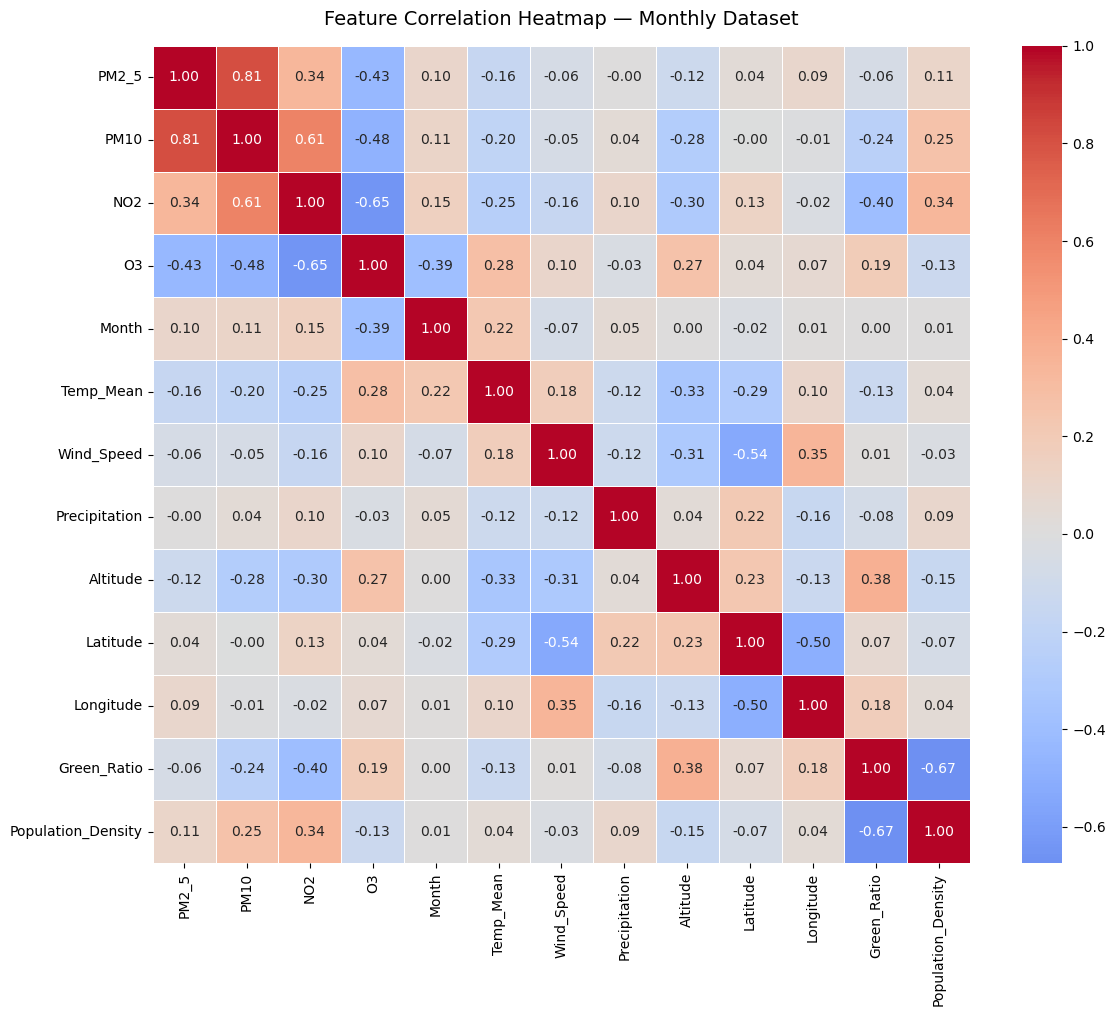

Saved to images/correlation_heatmap_monthly.png


In [38]:
# Feature Correlation Heatmap (monthly dataset, no lags)

df_monthly = pd.read_csv("df_model_monthly.csv")

# Select numeric features only
numeric_cols = [
    "PM2_5", "PM10", "NO2", "O3",
    "Month", "Temp_Mean", "Wind_Speed", "Precipitation",
    "Altitude", "Latitude", "Longitude",
    "Green_Ratio", "Population_Density"
]

corr = df_monthly[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax
)
ax.set_title("Feature Correlation Heatmap — Monthly Dataset", fontsize=14, pad=15)
plt.tight_layout()
plt.savefig("images/correlation_heatmap_monthly.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to images/correlation_heatmap_monthly.png")